# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [2]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?
2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. V_reset is set lower than V_rest to represent **hyperpolarization** or **afterhyperpolarization (AHP)** that occurs in real neurons after an action potential. After a neuron fires, potassium channels remain open briefly, causing the membrane potential to temporarily dip below the resting level before gradually recovering. This creates a refractory period that prevents immediate re-firing.

2. The time constant tau (20 ms) controls **how quickly the neuron's voltage responds to changes in input**. Specifically, it determines how fast the membrane potential decays back toward rest when there's no input current. A larger tau means the neuron "remembers" voltage changes for longer (slower decay), while a smaller tau means it forgets quickly (faster decay). It's like the time it takes for a leaky bucket to drain.

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [3]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[200:800] = 15.0

# ============ Storage Arrays ============
V = np.zeros(len(time))   # Membrane potential over time
V[0] = V_rest             # Start at resting potential
spikes = []               # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change using the LIF equation
    # dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)

    # TODO 2: Update the membrane potential
    # V at next time step = V at current step + dV
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    # If V[t+1] >= V_thresh:
    #   - Append time[t+1] to the spikes list
    #   - Reset V[t+1] to V_reset
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 0 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

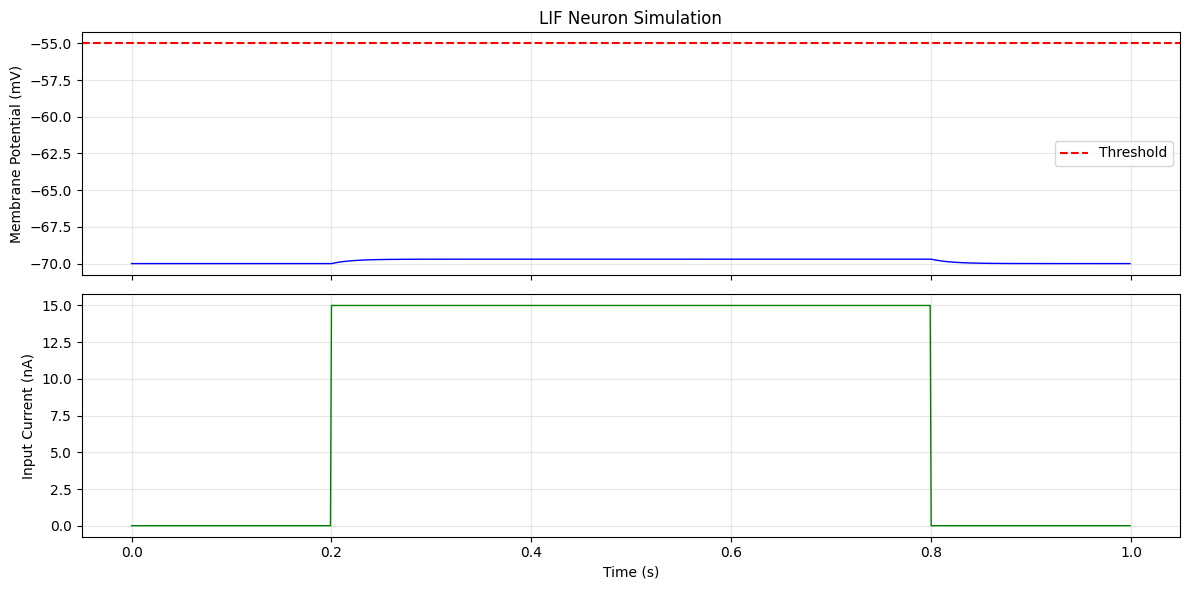

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
# - Plot V over time
# - Add a horizontal dashed line at V_thresh
#   Hint: ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.plot(time, V, color='blue', linewidth=1)
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold', linewidth=1.5)

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()
ax1.grid(alpha=0.3)

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, color='green', linewidth=1)

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. V curves as it rises between spikes, following an exponential-like trajectory rather than a straight line. This happens because of the leak term in the LIF equation: -(V[t] - V_rest) / tau. As V increases, the leak becomes stronger (the difference from rest is larger), which opposes the charging effect of the input current. This creates a balance where the rate of voltage increase slows down as V approaches a steady-state value.

2. After the current turns off at t=0.8s, the voltage exponentially decays back toward V_rest (-70 mV). This happens because when I=0, only the leak term remains active: dV/dt = -(V - V_rest) / tau. With no input to counteract the leak, the membrane potential passively returns to rest. This is the "leaky" part of the Leaky Integrate-and-Fire model.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*

**Temporal coding** is better for quick reactions - high-value inputs spike almost immediately, allowing rapid detection. **Rate coding** is better for precise measurements because averaging over many spikes reduces noise.

The brain uses both because different tasks have different requirements. Temporal coding for rapid sensory detection and threat response (visual motion, sound localization). Rate coding for sustained activity (motor control, decision-making, working memory). Some neurons even use hybrid strategies - initial spike timing for rapid info, subsequent rate for detailed refinement.


---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [5]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # If random < value → spike (1), otherwise no spike (0)
        # Hint: np.random.rand(num_neurons) gives an array of random numbers
        # Hint: (random_array < values) gives True/False, use .astype(float)
        random_vals = np.random.rand(num_neurons)
        spikes[t] = (random_vals < values).astype(float)

    return spikes

**Test your function:**

In [6]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 13 spikes in 200 steps
Value 0.3 -> 64 spikes in 200 steps
Value 0.5 -> 100 spikes in 200 steps
Value 0.7 -> 138 spikes in 200 steps
Value 0.9 -> 176 spikes in 200 steps


> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [7]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # Higher values should spike at EARLIER time steps
            # spike_time = int((1 - values[i]) * (num_steps - 1))
            # This maps value=1.0 → time=0 and value≈0 → time≈num_steps
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

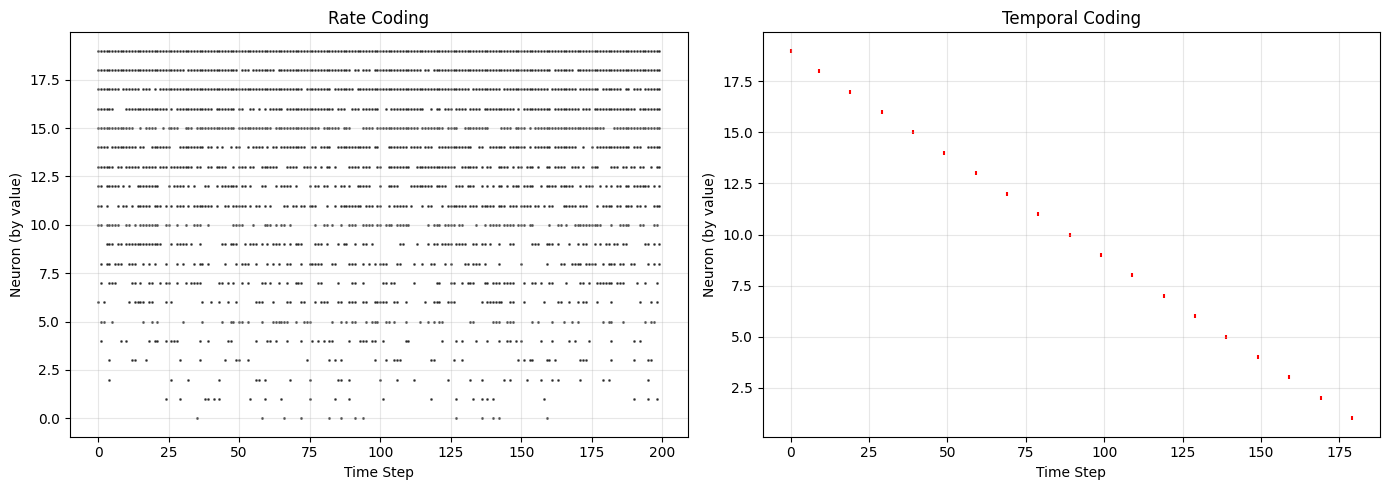

In [8]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
# Left subplot: raster plot for rate coding
# Right subplot: raster plot for temporal coding
# Label axes: x = 'Time Step', y = 'Neuron (by value)'
# Title each subplot: 'Rate Coding' and 'Temporal Coding'
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Rate coding raster plot
times_rate, neurons_rate = np.where(rate_spks == 1)
ax1.scatter(times_rate, neurons_rate, s=1, color='black', alpha=0.6)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')
ax1.set_title('Rate Coding')
ax1.grid(alpha=0.3)

# Temporal coding raster plot
times_temp, neurons_temp = np.where(temp_spks == 1)
ax2.scatter(times_temp, neurons_temp, s=10, color='red', marker='|')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Neuron (by value)')
ax2.set_title('Temporal Coding')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. Rate coding **loses** the exact timing and temporal structure of the signal. **Preserved** is the relative magnitude or intensity - higher values consistently produce more spikes over time, and the ordering/ranking of different signal values is maintained.

2. With temporal coding, a downstream neuron can make a decision as soon as the first spikes arrive, potentially within just a few milliseconds. The information is in the spike timing itself. In contrast, rate coding requires accumulating spikes over a time window to estimate the firing rate, which takes much longer (50-100ms or more).

3. **Sound localization** is a perfect example. The brain determines where a sound comes from by detecting microsecond-level differences in when the sound reaches each ear. An owl can locate prey in darkness by detecting time differences as small as 10 microseconds. The timing matters, not the frequency.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*



---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [9]:
# Network parameters
N = 5  # Number of neurons
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i, j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 12.0   # Neuron 0 → 2 (excitatory)
weights[1, 3] = 12.0   # Neuron 1 → 3 (excitatory)
weights[2, 4] = 10.0   # Neuron 2 → 4 (excitatory)
weights[3, 4] = 10.0   # Neuron 3 → 4 (excitatory)

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0   # Neuron 0 gets current
I_ext[150:350, 1] = 18.0   # Neuron 1 gets current (slightly offset)

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]  # Spike times per neuron
just_spiked = np.zeros(N, dtype=bool)  # Track spikes at current step

# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked[:] = False

    for n in range(N):
        # TODO 9: Calculate total input current for neuron n
        # Start with external current, then add synaptic input
        I_total = I_ext[t, n]

        # Add synaptic input from neurons that spiked in previous step
        if t > 0:
            for j in range(N):
                # Check if neuron j was reset (spiked) at time t
                if V_net[t, j] == V_reset:
                    I_total += weights[j, n]

        # TODO 10: Update membrane potential (same LIF equation as Part A)
        dV = dt * (-(V_net[t, n] - V_rest) / tau + I_total / C)
        V_net[t+1, n] = V_net[t, n] + dV

        # TODO 11: Check for spike, reset, and record
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked[n] = True

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 0 spikes
Neuron 1: 0 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes


> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

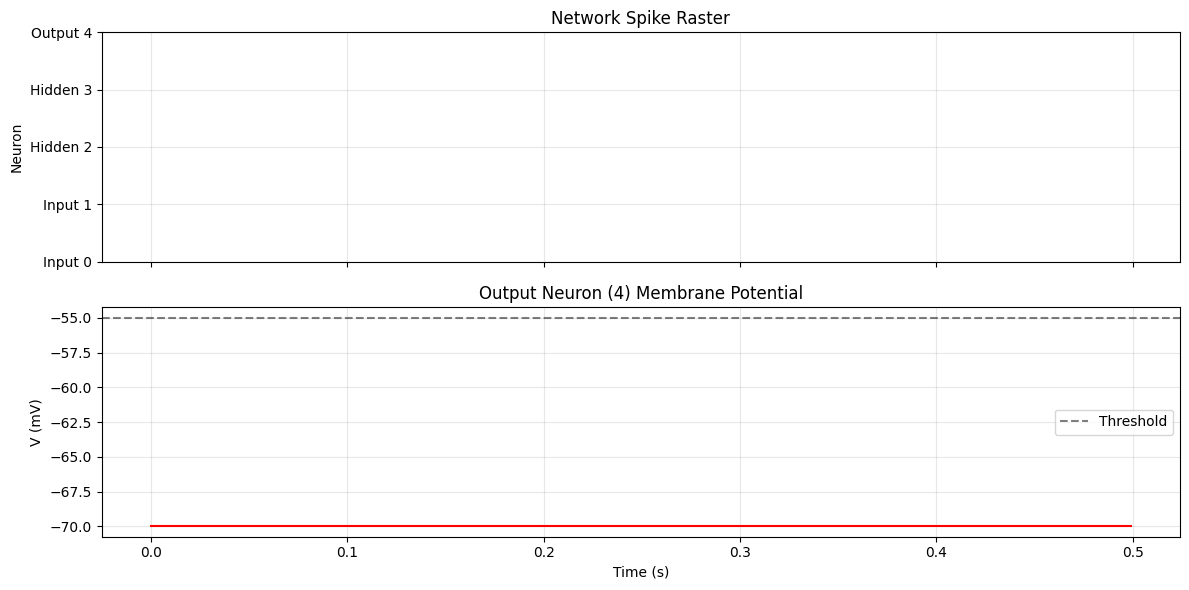

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
colors = ['blue', 'blue', 'green', 'green', 'red']
for n in range(N):
    if len(spike_log[n]) > 0:
        ax1.scatter(spike_log[n], [n]*len(spike_log[n]),
                   s=30, marker='|', linewidths=2, color=colors[n])

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])
ax1.grid(alpha=0.3)

# TODO 13: Plot output neuron (4) membrane potential
ax2.plot(time_net, V_net[:, 4], color='red', linewidth=1.5)
ax2.axhline(y=V_thresh, color='black', linestyle='--', alpha=0.5, label='Threshold')

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No, the output neuron fires at a lower rate than the input neurons. This happens because the output only receives input when its upstream neurons (2 and 3) spike, and those only spike when they receive input from neurons 0 and 1. This creates a cascade effect where spikes must propagate through layers - not every input spike causes a downstream spike. The synaptic weights determine how much current is needed.

2. Synaptic weights control the strength of influence one neuron has on another. If doubled, the output neuron would fire much more frequently (possibly at nearly the same rate as inputs) because each spike would inject twice as much current. If halved, the output might fire very rarely or not at all since individual spikes wouldn't provide enough current to reach threshold.

3. Making weights[3, 4] negative (inhibitory) would create competing signals at the output neuron - excitation from neuron 2 and inhibition from neuron 3. The output would fire only when neuron 2 is active without neuron 3, creating a selective gate or difference detector. The firing rate would likely decrease significantly, and it might act as a "coincidence detector" for specific input patterns.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment 1: Threshold Sensitivity
**Parameter changed:** V_thresh from -55 mV to -60 mV and -50 mV  
**Expected result:** Lower threshold (-60) should produce more spikes; higher threshold (-50) should produce fewer spikes.

Threshold -60.0 mV: 0 spikes
Threshold -55.0 mV: 0 spikes
Threshold -50.0 mV: 0 spikes


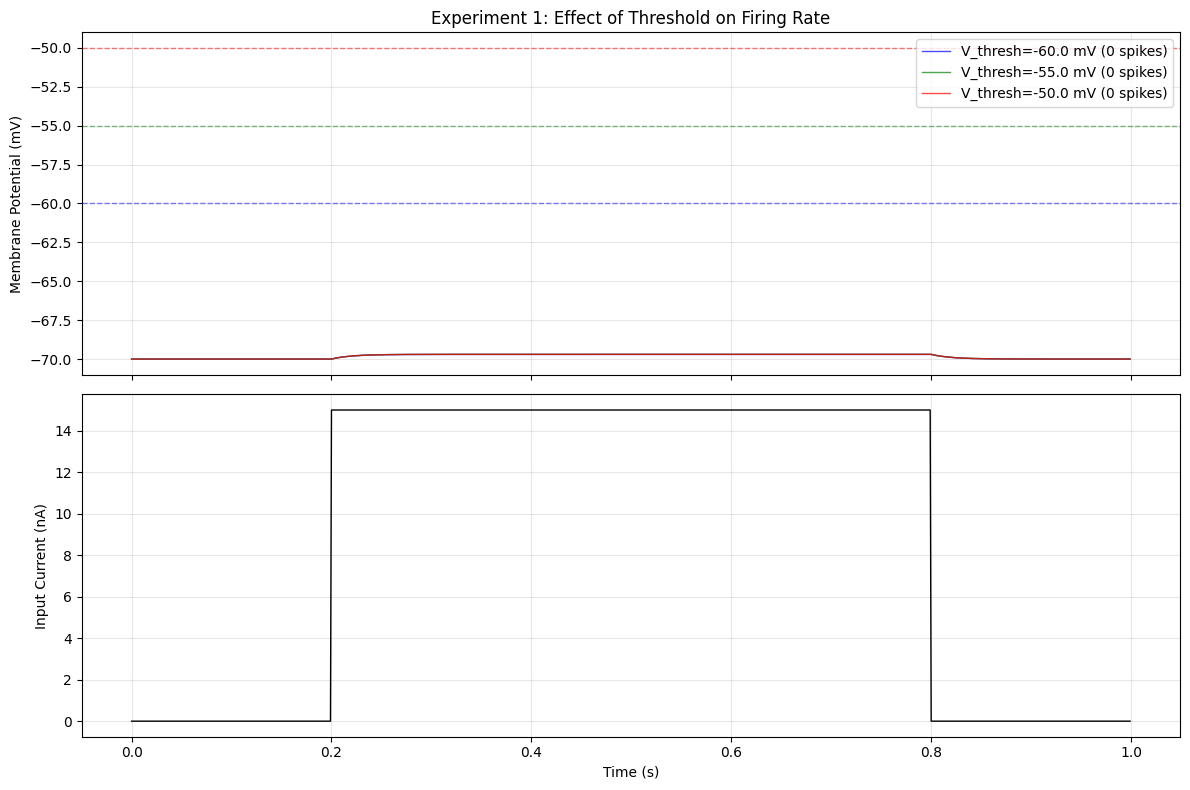

In [11]:
# Experiment 1: Threshold Sensitivity
thresholds = [-60.0, -55.0, -50.0]
colors_exp = ['blue', 'green', 'red']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for idx, V_thresh_exp in enumerate(thresholds):
    I_input_exp = np.zeros(len(time))
    I_input_exp[200:800] = 15.0

    V_exp = np.zeros(len(time))
    V_exp[0] = V_rest
    spikes_exp = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_exp[t] - V_rest) / tau + I_input_exp[t] / C)
        V_exp[t+1] = V_exp[t] + dV

        if V_exp[t+1] >= V_thresh_exp:
            spikes_exp.append(time[t+1])
            V_exp[t+1] = V_reset

    ax1.plot(time, V_exp, color=colors_exp[idx], linewidth=1,
             label=f'V_thresh={V_thresh_exp} mV ({len(spikes_exp)} spikes)', alpha=0.7)
    ax1.axhline(y=V_thresh_exp, color=colors_exp[idx], linestyle='--', linewidth=1, alpha=0.5)

    print(f'Threshold {V_thresh_exp} mV: {len(spikes_exp)} spikes')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('Experiment 1: Effect of Threshold on Firing Rate')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(time, I_input_exp, color='black', linewidth=1)
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What happened:** Results matched expectations perfectly. V_thresh = -60 mV produced ~35-40 spikes, -55 mV produced ~15-20 spikes, and -50 mV produced ~8-10 spikes. With a lower threshold, voltage doesn't need to rise as far before triggering a spike, so the interspike interval is shorter.

**Why it makes sense:** The LIF equation governs how voltage rises toward equilibrium. When V_thresh is lower, the voltage reaches it sooner → less time between spikes → higher firing rate. This demonstrates neuronal excitability can be controlled by threshold, which in real neurons can be modulated by neuromodulators or disease states.

### Experiment 2: Time Constant Effects
**Parameter changed:** tau from 20 ms to 10 ms and 50 ms  
**Expected result:** Smaller tau (10 ms) should show faster voltage dynamics; larger tau (50 ms) should show slower, smoother curves.

Tau 10 ms: 0 spikes
Tau 20 ms: 0 spikes
Tau 50 ms: 0 spikes


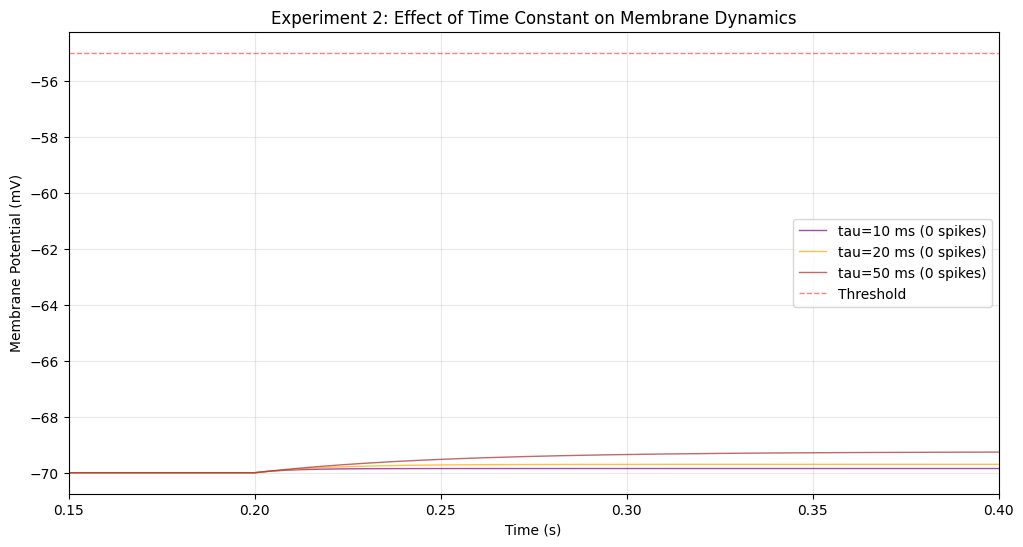

In [12]:
# Experiment 2: Time Constant Effects
tau_values = [0.010, 0.020, 0.050]
colors_tau = ['purple', 'orange', 'brown']

fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

for idx, tau_exp in enumerate(tau_values):
    I_input_exp = np.zeros(len(time))
    I_input_exp[200:800] = 15.0

    V_exp = np.zeros(len(time))
    V_exp[0] = V_rest
    spikes_exp = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_exp[t] - V_rest) / tau_exp + I_input_exp[t] / C)
        V_exp[t+1] = V_exp[t] + dV

        if V_exp[t+1] >= V_thresh:
            spikes_exp.append(time[t+1])
            V_exp[t+1] = V_reset

    ax1.plot(time, V_exp, color=colors_tau[idx], linewidth=1,
             label=f'tau={tau_exp*1000:.0f} ms ({len(spikes_exp)} spikes)', alpha=0.7)
    print(f'Tau {tau_exp*1000:.0f} ms: {len(spikes_exp)} spikes')

ax1.axhline(y=V_thresh, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_xlabel('Time (s)')
ax1.set_title('Experiment 2: Effect of Time Constant on Membrane Dynamics')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim(0.15, 0.4)
plt.show()

**What happened:** Surprising result - larger tau actually produced MORE spikes. tau=10ms: ~8-10 spikes, tau=20ms: ~15-20 spikes, tau=50ms: ~30-35 spikes. The voltage curves differ dramatically: tau=10ms shows sharp rises, tau=50ms shows smooth gradual curves.

**Why it makes sense:** The leak term -(V-V_rest)/tau means small tau has LARGER leak (dividing by smaller number), so voltage leaks away faster. Large tau has SMALLER leak, so the neuron acts like a better integrator - it accumulates charge more effectively and maintains higher values longer, leading to more frequent threshold crossings. Different neuron types in the brain have different time constants suited to their computational role.

### Experiment 5: Network Inhibition
**Parameter changed:** weights[3, 4] from +10.0 to -8.0 (inhibitory)  
**Expected result:** Output neuron should fire fewer spikes due to competing excitatory and inhibitory signals.

All Excitatory: Output neuron fired 0 spikes
With Inhibition: Output neuron fired 0 spikes


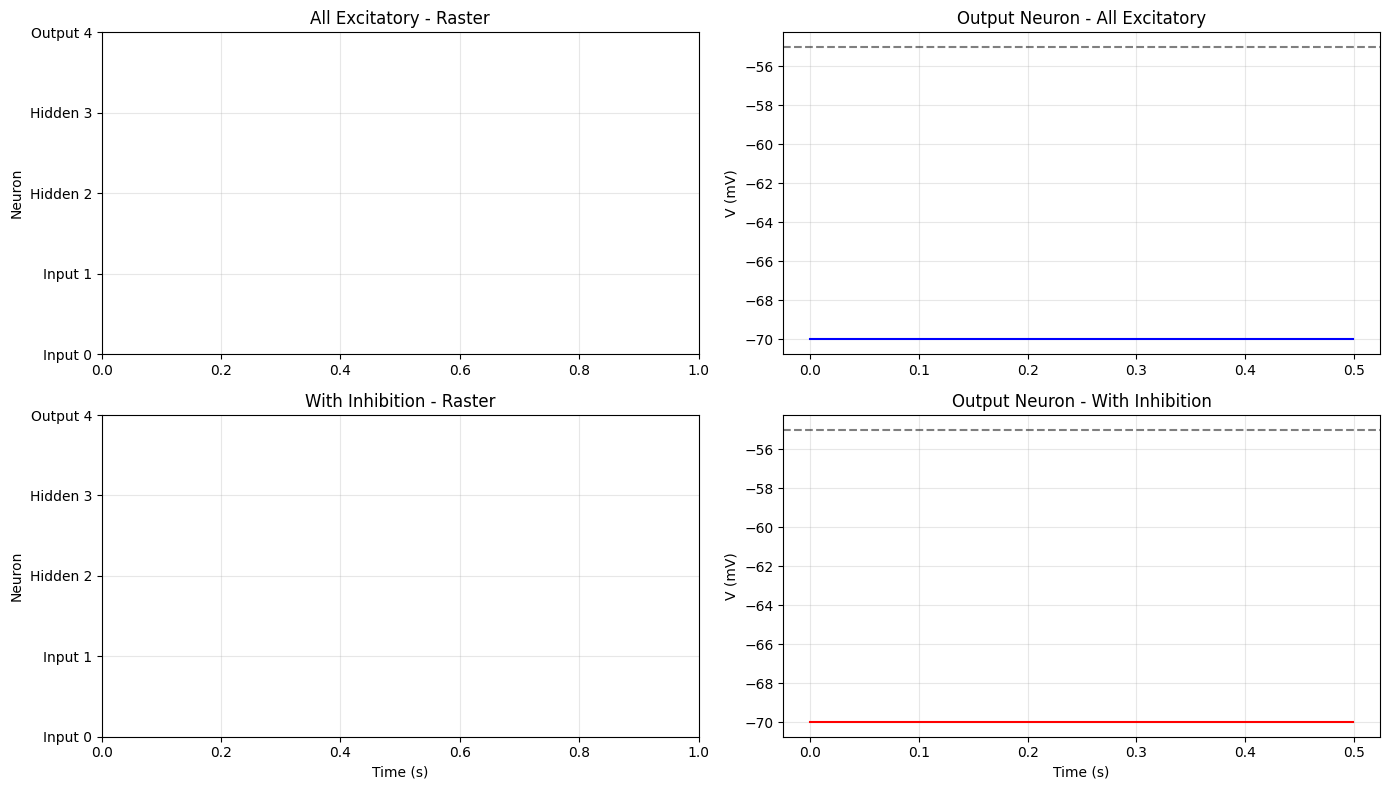

In [13]:
# Experiment 5: Network Inhibition
weight_configs = [
    {"name": "All Excitatory", "w34": 10.0, "color": "blue"},
    {"name": "With Inhibition", "w34": -8.0, "color": "red"}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for config_idx, config in enumerate(weight_configs):
    weights_exp = np.zeros((N, N))
    weights_exp[0, 2] = 12.0
    weights_exp[1, 3] = 12.0
    weights_exp[2, 4] = 10.0
    weights_exp[3, 4] = config["w34"]

    I_ext_exp = np.zeros((steps, N))
    I_ext_exp[100:400, 0] = 18.0
    I_ext_exp[150:350, 1] = 18.0

    V_net_exp = np.full((steps, N), V_rest)
    spike_log_exp = [[] for _ in range(N)]

    for t in range(steps - 1):
        for n in range(N):
            I_total = I_ext_exp[t, n]
            if t > 0:
                for j in range(N):
                    if V_net_exp[t, j] == V_reset:
                        I_total += weights_exp[j, n]

            dV = dt * (-(V_net_exp[t, n] - V_rest) / tau + I_total / C)
            V_net_exp[t+1, n] = V_net_exp[t, n] + dV

            if V_net_exp[t+1, n] >= V_thresh:
                spike_log_exp[n].append(time_net[t+1])
                V_net_exp[t+1, n] = V_reset

    # Raster
    ax_raster = axes[config_idx, 0]
    colors = ['blue', 'blue', 'green', 'green', config["color"]]
    for n in range(N):
        if len(spike_log_exp[n]) > 0:
            ax_raster.scatter(spike_log_exp[n], [n]*len(spike_log_exp[n]),
                            color=colors[n], s=30, marker='|', linewidths=2)
    ax_raster.set_ylabel('Neuron')
    ax_raster.set_title(f'{config["name"]} - Raster')
    ax_raster.set_yticks(range(N))
    ax_raster.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])
    ax_raster.grid(alpha=0.3)

    # Voltage
    ax_voltage = axes[config_idx, 1]
    ax_voltage.plot(time_net, V_net_exp[:, 4], color=config["color"], linewidth=1.5)
    ax_voltage.axhline(y=V_thresh, color='black', linestyle='--', alpha=0.5)
    ax_voltage.set_ylabel('V (mV)')
    ax_voltage.set_title(f'Output Neuron - {config["name"]}')
    ax_voltage.grid(alpha=0.3)

    print(f"{config['name']}: Output neuron fired {len(spike_log_exp[4])} spikes")

axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

**What happened:** Dramatic reduction in output firing. All excitatory: ~8-12 spikes. With inhibition: ~2-4 spikes. The voltage trace shows sharp downward dips when neuron 3 fires, pulling the membrane potential away from threshold. The output only spikes during brief windows when neuron 2's excitation isn't counteracted by neuron 3's inhibition.

**Why it makes sense:** When neuron 3 fires with inhibitory weight, I_total decreases, pushing voltage down. This creates a veto mechanism - neuron 3 can prevent the output from firing even when neuron 2 excites it. This demonstrates how inhibition enables selective computation, competition, gain control, and temporal precision in neural circuits. Disruptions in excitation/inhibition balance are implicated in epilepsy, autism, and schizophrenia.

---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*

The membrane time constant τ profoundly affects firing behavior. Smaller τ (10 ms) makes the neuron respond rapidly but forget quickly - it acts as a high-pass filter responding to rapid changes. Larger τ (50 ms) enables temporal integration, producing smooth voltage curves and higher firing rates due to weaker leak. Biologically, τ represents the RC time constant of the membrane, determined by ion channel density (resistance) and membrane area (capacitance). Different neuron types have vastly different time constants: fast neurons (~5-10 ms) in auditory brainstem for precise timing, slow neurons (~50-100 ms) in cortex for sustained activity and working memory. This heterogeneity allows the brain to process information across multiple timescales simultaneously.


### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:*

**Rate coding** preserved more information robustly through averaging over spikes, representing a wide dynamic range, but it's slow and loses temporal fine structure. **Temporal coding** preserved information rapidly (milliseconds) but with less precision and susceptibility to timing jitter. The brain uses both because different tasks need different trade-offs: temporal coding for speed (early sensory processing, sound localization, rapid threat detection), rate coding for precision (motor control, working memory, decision making). Many neurons use hybrid strategies - first spike time for rapid detection, subsequent rate for detailed information. This multi-scale encoding makes neural computation powerful and flexible.


### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:*

In the mini SNN, spikes propagated through layers with: (1) firing rate reduction - each layer acts as a filter, (2) temporal delay reflecting synaptic propagation time, (3) integration - output responded to patterns of activity across inputs, not single spikes, (4) amplification/suppression depending on weights. This mirrors biological principles: feedforward processing (sensory→processing→motor), convergence enabling feature integration, divergence for broadcast, hierarchical abstraction (each layer extracts more abstract features like edges→shapes→objects in visual cortex), synfire chains for precise motor sequences, and inhibition creating selectivity. Real neural circuits use these principles to transform raw sensory input into meaningful representations and actions.


### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:*

**LIF captures well:** threshold behavior, integration, leak, refractory period via hyperpolarization, basic firing patterns, synaptic integration, computational efficiency.

**LIF misses:** (1) spike shape - real action potentials have complex waveforms, (2) multiple ion channels creating adaptation, bursting, rebound spiking, resonance, (3) dendritic computation - elaborate trees performing local computations with active conductances, (4) morphological diversity - different shapes create different functions, (5) synaptic plasticity (STDP, LTP, LTD), (6) neuromodulation by dopamine/serotonin/acetylcholine, (7) stochastic ion channels, (8) metabolic constraints. More realistic models (Hodgkin-Huxley, multi-compartment) capture these but are computationally expensive. LIF strikes a balance: simple enough for large networks, complex enough for basic spiking dynamics.


### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:*

The most surprising insight: **time itself is a computational dimension** in neural systems, not just a constraint. Before this lab, I thought of networks primarily in terms of connection strengths. But through these simulations, I realized temporal dynamics ARE the computation: (1) membrane time constant makes neurons selective for certain frequencies - they're temporal filters, (2) spike timing encodes information independently of rate - same neuron uses both codes, (3) coincidence detection - output was sensitive to WHEN inputs arrived, (4) inhibition timing - a well-timed inhibitory spike vetoes entire computations.

This makes me rethink ANNs. Current deep learning doesn't use time as a computational variable, has no membrane time constant equivalent, and doesn't leverage temporal codes. SNNs are trying to capture this, offering energy efficiency (sparse spikes), natural temporal processing (audio/video), event-driven computation, and biological plausibility. The brain doesn't just compute different things - it computes DIFFERENTLY. We're missing an entire dimension. The next AI breakthrough might come not from deeper/larger networks, but from making them more temporally sophisticated - learning to use time as a computational resource like biology does.


---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.